## 导入库

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 
# This line is used to display plots inline in Jupyter notebooks
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("All libraries imported successfully")

All libraries imported successfully


## 加载数据

In [7]:
# Load the iris dataset
iris=datasets.load_iris()
print("数据类型: ", type(iris))
print("\n可用的键: ", iris.keys())
print("数据集的特征名称: ", iris.feature_names)
print("数据集的目标名称: ", iris.target_names)
print("\n数据集描述的前五百字符: \n", iris.DESCR[:500])

# Create a DataFrame from the iris dataset

数据类型:  <class 'sklearn.utils._bunch.Bunch'>

可用的键:  dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
数据集的特征名称:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
数据集的目标名称:  ['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

数据集描述的前五百字符: 
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==

## 探索数据

In [8]:
# 分离特征和标签
X=iris.data
#特征矩阵大写X是惯例
y=iris.target
#标签向量小写y是惯例
print("特征矩阵X的形状: ", X.shape)
print("标签向量y的形状: ", y.shape)     
print("\n前五个样本的特征: \n", X[:5])
print("\n前五个样本的标签: \n", y[:5])
df=pd.DataFrame(X,columns=iris.feature_names)
df['target']=y
df['target_names']=[iris.target_names[t] for t in y]  #将数字标签转为名称

print("前五行数据: \n", df.head())
print("\n数据集的统计描述: \n", df.describe())
print("\n数据集中每个类别的样本数量: \n", df['target_names'].value_counts())



特征矩阵X的形状:  (150, 4)
标签向量y的形状:  (150,)

前五个样本的特征: 
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

前五个样本的标签: 
 [0 0 0 0 0]
前五行数据: 
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  

数据集的统计描述: 
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333         

## 简化任务 二分类

In [9]:
#原始是三分类，为简化先做二分类，只区分山鸾尾（0）和变色鸾尾（1）
# 筛选出前两类数据
mask = y < 2# 只选取标签为0和1的样本
X_binary = X[mask]
y_binary = y[mask]
print("二分类数据形状")
print("二分类特征矩阵X_binary的形状: ", X_binary.shape)
print("二分类标签向量y_binary的形状: ", y_binary.shape)
print("二分类标签分布：")
unique, counts=np.unique(y_binary, return_counts=True)
for label, count in zip(unique, counts):
    print(f"标签 {label} ({iris.target_names[label]}) 的样本数量: {count}")
    #简化问题有助于核心流程的演示，后续可以扩展到多分类

二分类数据形状
二分类特征矩阵X_binary的形状:  (100, 4)
二分类标签向量y_binary的形状:  (100,)
二分类标签分布：
标签 0 (setosa) 的样本数量: 50
标签 1 (versicolor) 的样本数量: 50


## 划分训练集和测试集

In [10]:
#划分数据
#random_state参数确保每次运行代码时划分结果相同，便于调试和结果复现
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"训练集/测试集比例: {X_train.shape[0] / X_binary.shape[0]:.0%} / {X_test.shape[0] / X_binary.shape[0]:.0%}")
print("\n训练集类别分布: ")
print(np.bincount(y_train))
print("\n测试集类别分布: ")
print(np.bincount(y_test))

训练集大小: 70 样本
测试集大小: 30 样本
训练集/测试集比例: 70% / 30%

训练集类别分布: 
[33 37]

测试集类别分布: 
[17 13]


## 训练模型

In [11]:
#创建模型实例
model =LogisticRegression()
#训练模型
model.fit(X_train, y_train)
print("模型训练完成")
print(f"模型参数(系数w): {model.coef_}")
print(f"模型参数(截距b): {model.intercept_}")


模型训练完成
模型参数(系数w): [[ 0.44975352 -0.81943865  2.15275297  0.90757282]]
模型参数(截距b): [-6.33875304]


## 预测评估

In [12]:
#预测
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

#评估准确率
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print(f"训练集准确率: {train_accuracy:.2%}")
print(f"测试集准确率: {test_accuracy:.2%}")
#混淆矩阵
print("\n测试集混淆矩阵: \n", confusion_matrix(y_test, y_test_pred))
print("\n混淆矩阵解读:")
print("[[真负 假正]]")
print("[[假负 真正]]")
print("\n分类报告: \n", classification_report(y_test, y_test_pred, target_names=iris.target_names[:2]))

训练集准确率: 100.00%
测试集准确率: 100.00%

测试集混淆矩阵: 
 [[17  0]
 [ 0 13]]

混淆矩阵解读:
[[真负 假正]]
[[假负 真正]]

分类报告: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 深入理解模型

In [13]:
#查看预测概率
print("前五个测试样本的预测概率: \n")
probabilities=model.predict_proba(X_test)[:5]
for i, (probs, true_label,pred_label) in enumerate(zip(probabilities, y_test[:5], y_test_pred[:5])):
    print(f"样本 {i}: 类别0概率={probs[0]:.4f}, 类别1概率={probs[1]:.4f}, 真实标签={true_label}, 预测标签={pred_label}")
    
#手动计算一个样本的预测概率
print("\n手动计算第一个测试样本的预测概率: ")
sample=X_test[0].reshape(1, -1)  #保持二维输入
print(f"样本特征值: {sample[0]}")

model_preb=model.predict(sample)[0]
model_prob=model.predict_proba(sample)[0][1] #类别1的概率
#手动计算概率
z=np.dot(sample, model.coef_.T) + model.intercept_  
manual_prob=1 / (1 + np.exp(-z))  #sigmoid函数
print(f"模型预测类别: {model_preb}")    
print(f"模型预测类别1的概率: {model_prob:.4f}")
print(f"手动计算的类别1概率: {manual_prob[0][0]:.4f}")  
print("两者是否接近: ", np.isclose(model_prob, manual_prob[0][0]))

#模型预测


前五个测试样本的预测概率: 

样本 0: 类别0概率=0.0014, 类别1概率=0.9986, 真实标签=1, 预测标签=1
样本 1: 类别0概率=0.0173, 类别1概率=0.9827, 真实标签=1, 预测标签=1
样本 2: 类别0概率=0.0035, 类别1概率=0.9965, 真实标签=1, 预测标签=1
样本 3: 类别0概率=0.9662, 类别1概率=0.0338, 真实标签=0, 预测标签=0
样本 4: 类别0概率=0.9374, 类别1概率=0.0626, 真实标签=0, 预测标签=0

手动计算第一个测试样本的预测概率: 
样本特征值: [6.  2.7 5.1 1.6]
模型预测类别: 1
模型预测类别1的概率: 0.9986
手动计算的类别1概率: 0.9986
两者是否接近:  True


## 可视化


C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_18120\2096121290.py:31: UserWarning: Glyph 26631 (\N{CJK 

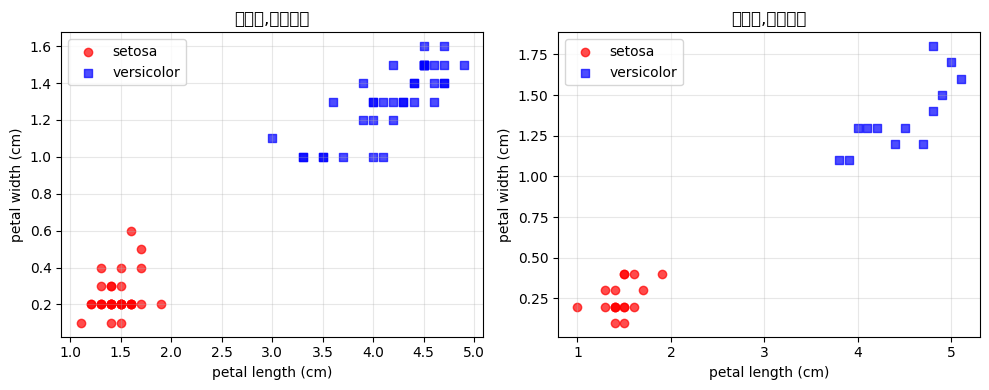

d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\1\Lib\site-packages\IPython\core\pylabtools.py:170: 

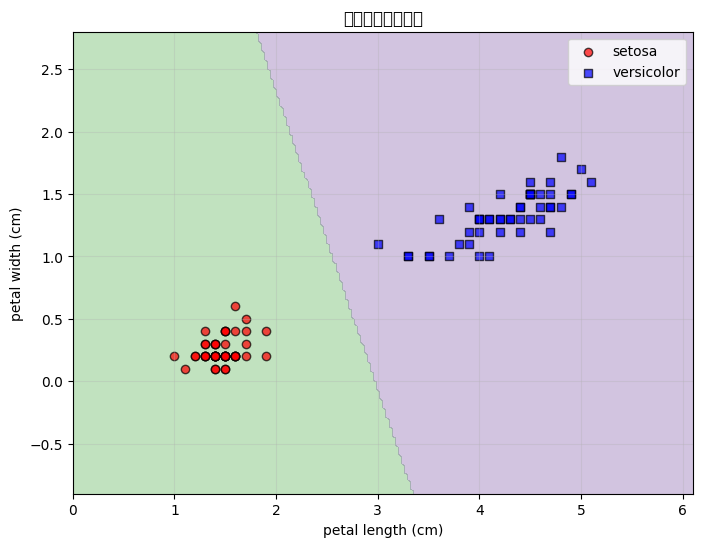

In [17]:
# 只用花瓣长度和宽度两个特征进行二分类和可视化
X_two_features = X_binary[:, 2:4]
X_train, X_test, y_train, y_test = train_test_split(X_two_features, y_binary, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# 绘制两个特征的散点图
plt.figure(figsize=(10,4))
# 训练集
plt.subplot(1,2,1)
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_train == label)
    plt.scatter(X_train[mask,0], X_train[mask,1], c=color, marker=marker, label=iris.target_names[label], alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("训练集,真实标签")
plt.legend()
plt.grid(True, alpha=0.3)

# 测试集预测结果
plt.subplot(1,2,2)
y_test_pred = model.predict(X_test)
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_test_pred == label)
    plt.scatter(X_test[mask,0], X_test[mask,1], c=color, marker=marker, label=iris.target_names[label], alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("测试集,预测标签")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绘制决策边界
plt.figure(figsize=(8,6))
x_min, x_max = X_two_features[:, 0].min() - 1, X_two_features[:, 0].max() + 1
y_min, y_max = X_two_features[:, 1].min() - 1, X_two_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(-0.5, 2), cmap=plt.cm.Paired)
# 绘制所有数据点
for label, color, marker in zip([0,1], ['red','blue'], ['o','s']):
    mask = (y_binary == label)
    plt.scatter(X_two_features[mask,0], X_two_features[mask,1], c=color, marker=marker, label=iris.target_names[label], edgecolor='k', alpha=0.7)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title("决策边界与数据点")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# 10.1 尝试不同的正则化强度
print("不同正则化强度C的效果:")
for C in [0.01, 0.1, 1, 10, 100]:
    model_tmp = LogisticRegression(C=C, random_state=42, max_iter=1000)
    model_tmp.fit(X_train, y_train)
    acc = model_tmp.score(X_test, y_test)
    print(f"C={C:5}: 测试集准确率={acc:.3f}, 系数绝对值平均={np.mean(np.abs(model_tmp.coef_)):.3f}")

# 10.2 尝试不划分测试集会怎样（错误示范）
print("\n--- 警告：错误示范 ---")
model_wrong = LogisticRegression(random_state=42)
model_wrong.fit(X_binary, y_binary)  # 用全部数据训练
y_wrong_pred = model_wrong.predict(X_binary)  # 用同样数据预测
wrong_acc = accuracy_score(y_binary, y_wrong_pred)
print(f"用全部数据训练并在相同数据上评估的准确率: {wrong_acc:.1%}")
print("这个数字具有欺骗性！它不代表模型泛化能力。")

不同正则化强度C的效果:
C= 0.01: 测试集准确率=1.000, 系数绝对值平均=0.239
C=  0.1: 测试集准确率=1.000, 系数绝对值平均=0.837
C=    1: 测试集准确率=1.000, 系数绝对值平均=1.702
C=   10: 测试集准确率=1.000, 系数绝对值平均=2.846
C=  100: 测试集准确率=1.000, 系数绝对值平均=4.315

--- 警告：错误示范 ---
用全部数据训练并在相同数据上评估的准确率: 100.0%
这个数字具有欺骗性！它不代表模型泛化能力。
